In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt



In [2]:
N = 10_000_000


python_list = list(range(N))

start = time.perf_counter()

for i in range(N):
    python_list[i] *= 2

python_time = time.perf_counter() - start
print(f"Python loop time : {python_time:.6f} sec")

Python loop time : 2.090007 sec


In [3]:
numpy_array = np.arange(N, dtype=np.int64)

start = time.perf_counter()

numpy_array *= 2

numpy_time = time.perf_counter() - start
print(f"NumPy time       : {numpy_time:.6f} sec")

NumPy time       : 0.006860 sec


In [4]:
print(f"Speedup          : {python_time/numpy_time:.2f}x")

Speedup          : 304.64x



Latency per element
Python : 209.00 ns
NumPy  : 0.69 ns


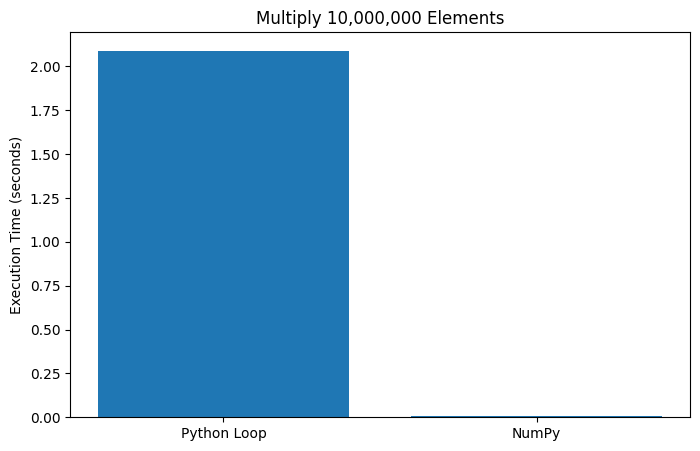

In [5]:
# Latency per element
python_latency_ns = python_time / N * 1e9
numpy_latency_ns = numpy_time / N * 1e9

print(f"\nLatency per element")
print(f"Python : {python_latency_ns:.2f} ns")
print(f"NumPy  : {numpy_latency_ns:.2f} ns")

# ----------------------------
# Visualization
# ----------------------------
methods = ["Python Loop", "NumPy"]
times = [python_time, numpy_time]

plt.figure(figsize=(8,5))
plt.bar(methods, times)
plt.ylabel("Execution Time (seconds)")
plt.title(f"Multiply {N:,} Elements")
plt.show()

In [6]:
import sys

x = 5

print(type(x))
print(sys.getsizeof(x))
print(id(x))

<class 'int'>
28
11645480


In [7]:
  import sys

arr = [1,2,3,4,5]

print(type(arr))
print(sys.getsizeof(arr))

for x in arr:
    print(type(x), sys.getsizeof(x))

<class 'list'>
104
<class 'int'> 28
<class 'int'> 28
<class 'int'> 28
<class 'int'> 28
<class 'int'> 28


In [8]:
import numpy as np

arr = np.array([1,2,3,4,5], dtype=np.int64)

print(type(arr))
print(arr.dtype)
print(arr.nbytes)
print(arr.itemsize)

<class 'numpy.ndarray'>
int64
40
8


In [9]:
arr = [1,2,3,4,5]

for x in arr:
    print(id(x))

11645352
11645384
11645416
11645448
11645480


In [10]:
import numpy as np

arr = np.array([1,2,3,4,5], dtype=np.int64)

print(arr.ctypes.data)

33670064


In [11]:
for i in range(len(arr)):
    print(arr.ctypes.data + i * arr.itemsize)

33670064
33670072
33670080
33670088
33670096


In [12]:
import numpy as np
import sys

N = 1_000_000

python_list = list(range(N))
numpy_array = np.arange(N, dtype=np.int64)

python_memory = (
    sys.getsizeof(python_list)
    + sum(sys.getsizeof(x) for x in python_list)
)

numpy_memory = numpy_array.nbytes

print(f"Python List : {python_memory/1024/1024:.2f} MB")
print(f"NumPy Array : {numpy_memory/1024/1024:.2f} MB")

Python List : 34.33 MB
NumPy Array : 7.63 MB


In [13]:
import numpy as np

arr = np.array([1,2,3], dtype=np.int64)

print(arr.tobytes())

b'\x01\x00\x00\x00\x00\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x00\x03\x00\x00\x00\x00\x00\x00\x00'


In [14]:
import numpy as np

python_list = [1,2,3,4,5]
numpy_array = np.array([1,2,3,4,5], dtype=np.int64)

print("Python list element addresses:")
for x in python_list:
    print(id(x))

print("\nNumPy element addresses:")
base = numpy_array.ctypes.data

for i in range(len(numpy_array)):
    print(base + i * numpy_array.itemsize)

Python list element addresses:
11645352
11645384
11645416
11645448
11645480

NumPy element addresses:
33670064
33670072
33670080
33670088
33670096


In [15]:
import numpy as np
import time

sizes = [
    1_000,
    10_000,
    100_000,
    1_000_000,
    10_000_000,
    50_000_000
]

for n in sizes:
    arr = np.arange(n, dtype=np.int64)

    start = time.perf_counter()
    arr *= 2
    elapsed = time.perf_counter() - start

    print(
        f"{n:>10,d} elements : "
        f"{elapsed:.6f} sec"
    )

     1,000 elements : 0.000304 sec
    10,000 elements : 0.000011 sec
   100,000 elements : 0.000048 sec
 1,000,000 elements : 0.000596 sec
10,000,000 elements : 0.005710 sec
50,000,000 elements : 0.026562 sec
